# Imports

In [1]:
%reload_ext autoreload
%autoreload 2


from stnd.utility.data_utils import make_or_load_from_cache
from stnd.utility.utils import apply_random_seed
import sys
import os
import sklearn
import numpy as np
import pandas as pd
import pickle
import torch

ROOT_PATH = os.path.join(os.path.dirname(os.path.abspath("")))
sys.path.insert(0, ROOT_PATH)
from experiments import (
    RANDOM_SEED,
    make_train_test_model_embeddings,
    make_cache_subpath,
    make_disagreement_scores_dict,
    make_fitted_weights
)
from utils import (
    lb_scenarios as LB_SCENARIOS,
    dump_pickle,
    load_pickle,
    prepare_and_split_data
)
from plots import (
    MODEL_OUTPUTS_PATH,
    load_scores,
    safe_spearmanr
)
from selection import sample_items
from run_experiment import load_and_split_model_outputs
from acc import (
    compute_true_acc,
    compute_acc_knn
)
from scripts.evaluate_mmlu import evaluate_mmlu
from utils_for_notebooks import (
    read_per_model_info,
    openllmname_to_hf_model_id
)
sys.path.pop(0);

/home/oh/arubinstein17/github/disco-public/envs/disco_env_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Evaluate new model

## Get ground truth

### Take from leaderboard snapshot

In [2]:
df = pd.read_csv(os.path.join(ROOT_PATH, "benchmark_csvs","open-llm-leaderboard.csv"))
small_models = df[df['#Params (B)'] <= 8]
small_models.head(n=10)


,T,Model,Average ⬆️,ARC,HellaSwag,MMLU,TruthfulQA,Winogrande,GSM8K,Type,...,Weight type,Precision,Merged,Hub License,#Params (B),Hub ❤️,Available on the hub,Model sha,Flagged,MoE
14,🔶,alnrg2arg/test2_4,75.28,73.55,88.87,64.63,69.77,84.45,70.43,fine-tuned,...,Original,bfloat16,True,apache-2.0,7.24,0.0,False,ed17cf5af87733ffd7836ab99f27991544ba2547,False,False
16,🟦,udkai/Garrulus,75.16,73.29,88.87,64.57,68.23,91.48,64.52,RL-tuned,...,Original,float16,False,apache-2.0,7.24,10.0,True,cd2fa5c2188588b903fff2070a389db3b24031a4,True,False
18,🟦,eren23/slerp-test-turdus-beagle,75.11,73.55,88.85,64.62,69.69,83.90,70.05,RL-tuned,...,Original,bfloat16,True,apache-2.0,7.24,0.0,True,f2aef36538bb0c7aab30ffe889e12b72f51a6816,False,False
23,?,rwitz2/go-bruins-v2.1.1,74.95,72.87,88.33,65.18,69.80,82.24,71.27,NaN,...,Original,bfloat16,False,cc,7.24,22.0,True,bd56295eab54eaacbb3af6ecb88b9434d9966d4e,True,False
25,🔶,nfaheem/Marcoroni-7b-DPO-Merge,74.90,73.04,88.80,64.24,70.47,85.24,67.63,fine-tuned,...,Original,float16,True,apache-2.0,7.24,1.0,True,e3085d8aacffbf46b95e263bde509fce70577a26,False,False
26,🔶,quantumaikr/quantum-dpo-v0.1,74.87,72.53,88.37,65.29,69.92,82.32,70.81,fine-tuned,...,Original,float16,False,cc-by-nc-4.0,7.24,2.0,True,09cbfe6569bcdddf623e9990498e9ad07345ad6a,True,False
27,🔶,jan-hq/trinity-v1,74.80,72.27,88.36,65.20,69.31,82.00,71.65,fine-tuned,...,Original,bfloat16,True,apache-2.0,7.24,11.0,True,34974ae99668c381be0871778e3c42958544f70e,True,False
28,🔶,janai-hq/trinity-v1,74.80,72.27,88.36,65.20,69.31,82.00,71.65,fine-tuned,...,Original,bfloat16,True,apache-2.0,7.24,4.0,True,09da1a24f84c96b8c09f2c07038986e28cc24ad5,True,False
29,🔶,mlabonne/Beagle14-7B,74.76,72.95,87.95,64.70,68.88,82.64,71.42,fine-tuned,...,Original,bfloat16,True,apache-2.0,7.24,8.0,True,a5d1b1f831efe38df3b6ac125764a87ed094e282,False,False
30,🔶,alnrg2arg/test2_3,74.76,72.95,88.42,64.80,68.40,84.14,69.83,fine-tuned,...,Original,bfloat16,True,apache-2.0,7.24,0.0,True,e2c681fa4680ee19ca9758a2289da7d168546672,False,False


In [3]:
try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
except:
    print("transformers not installed; run `pip install transformers`")


model_id = "alnrg2arg/test2_4"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

Loading checkpoint shards: 100%|██████████| 2/2 [00:09<00:00,  4.53s/it]


### Eval on the whole dataset to compute ground truth from scratch

In [ ]:
evaluate_mmlu(
    model_id=model_id,
    subset="all",
    num_fewshot=5,
    max_samples=None,
    batch_size=4,
)

## DISCO-eval

In [ ]:
# get anchor points
# get predictor
# get outputs for anchor points, cache
# predict with predictor
# compare to ground truth

# Debug

In [5]:
bench = "mmlu_fields"
data, scenarios, set_of_rows, data_path = load_and_split_model_outputs(
    bench=bench,
    split='noniid',
    model_outputs_path=MODEL_OUTPUTS_PATH,
    text_to_vector=None,
    return_data_path=True,
    subsample_validation=False,
)

chosen_scenarios = list(scenarios.keys())
split_number = 0
iterations = 5
rows_to_hide = set_of_rows[split_number]


40 425


In [3]:
print(data['data']['harness_arc_challenge_25']['correctness'].shape)

(1172, 425)


In [4]:
(
    scores_train,
    predictions_train,
    predictions_test,
    scores_test,
    balance_weights,
    scenarios_position,
    subscenarios_position,
) = prepare_and_split_data(
    chosen_scenarios,
    scenarios,
    data,
    rows_to_hide=rows_to_hide,
    n_source_models=None,
)

In [5]:
sampling_names = ["high-disagreement"]
disagreement_type = "pds"
disagreement_scores_dict = make_disagreement_scores_dict(
    config={
        "sampling_names": sampling_names,
        "predictions_train": predictions_train,
        "disagreement_type": disagreement_type,
        "vary_selection": False,
        "iterations": iterations
    }
)

In [6]:

number_items = [100]
iterations = 5
sampling_name = sampling_names[0]
number_item = number_items[0]
seen_items_dic = {sampling_name: {}}
apply_random_seed(RANDOM_SEED)
samples = sample_items(
    number_item,
    iterations,
    sampling_name,
    chosen_scenarios,
    scenarios,
    subscenarios_position,
    responses_test=scores_test,
    scores_train=scores_train,
    predictions_train=predictions_train,
    scenarios_position=scenarios_position,
    A=None,
    B=None,
    balance_weights=balance_weights,
    disagreement_scores_dict=disagreement_scores_dict,
    skip_irt=True,
)
(
    _,
    seen_items_dic[sampling_name][number_item],
    _,
    _
) = samples

In [7]:
# load embeddings
# cache_path = ""
# cache = load_pickle(cache_path)
# scenario_name = "mmlu"
# split_number = 0
# emb_cache_path = (
#     make_cache_subpath(
#         cache, scenario_name, split_number, f"embeddings_path"
#     )
# )

pca = 256
apply_softmax_to_predictions = True
(
    train_models_embeddings,
    test_models_embeddings,
) = make_train_test_model_embeddings(
    emb_config={
        "sampling_names": sampling_names,
        "number_items": number_items,
        "iterations": iterations,
        "predictions_train": predictions_train,
        "seen_items_dic": seen_items_dic,
        "predictions_test": predictions_test,
        "seen_items_dic": seen_items_dic,
        "pca": pca,
        "apply_softmax": apply_softmax_to_predictions,
    }
)



# make_or_load_from_cache(
#     object_name="train_test_model_embeddings",
#     object_config={
#         "sampling_names": sampling_names,
#         "number_items": number_items,
#         "iterations": iterations,
#         "predictions_train": predictions_train,
#         "seen_items_dic": seen_items_dic,
#         "predictions_test": predictions_test,
#         "seen_items_dic": seen_items_dic,
#         "pca": pca,
#         "apply_softmax": apply_softmax_to_predictions,
#     },
#     make_func=make_train_test_model_embeddings,
#     cache_path=emb_cache_path,
# )

Computing embeddings: 100%|██████████| 1/1 [00:05<00:00,  5.03s/it]


In [8]:
train_model_indices = list(range(scores_train.shape[0]))
train_model_true_accs = compute_true_acc(
    scores_train,
    balance_weights,  # sample -> sample weight
    scenarios_position,  # scenario -> list of sample indices
    chosen_scenarios,
    train_model_indices,
    train_model_indices,  # they are not the global indices, but the contiguous indices of train models after removing test models
)

In [9]:

    # "RandomForestRegressor_100": {
    #     "class_path": "sklearn.ensemble.RandomForestRegressor",
    #     "params": {"n_estimators": 100}
    # },

fitted_model_type = "RandomForestRegressor_100"
chosen_fitting_methods = [
    (fitted_model_type, (sklearn.ensemble.RandomForestRegressor, {"n_estimators": 100}))
]
scenario = bench.split("_")[0]
fitted_weights = make_fitted_weights(
    config={
        "sampling_names": sampling_names,
        "number_items": number_items,
        "iterations": iterations,
        "train_models_embeddings": train_models_embeddings,
        "train_model_true_accs": train_model_true_accs,
        "scenario": scenario,
        "cache_path": "./cache_for_notebook",
        "chosen_fitting_methods": chosen_fitting_methods,
        "skip_iterations_when_fixed_sampling": False,
    }
)

# make_or_load_from_cache(
#     object_name="fitted_weights",
#     object_config={
#         "sampling_names": sampling_names,
#         "number_items": number_items,
#         "iterations": iterations,
#         "train_models_embeddings": train_models_embeddings,
#         "train_model_true_accs": train_model_true_accs,
#         "scenario": bench,
#         "cache_path": fitted_weights_cache_path,
#         "chosen_fitting_methods": chosen_fitting_methods,
#     },
#     make_func=make_fitted_weights,
#     cache_path=fitted_weights_cache_path,
# )

In [10]:
predictors_per_seed = fitted_weights[sampling_names[0]][100]
target_model_embeddings_per_seed = test_models_embeddings[sampling_names[0]][100]
predicted_accs = {}
predicted_accs_knn = {}
for seed in range(iterations):
    fitted_model = predictors_per_seed[seed][fitted_model_type]
    target_model_embeddings = target_model_embeddings_per_seed[seed]
    for target_model_idx in range(target_model_embeddings.shape[0]):
        test_model_embedding = target_model_embeddings[target_model_idx]
        fitted_acc = fitted_model.predict(
            test_model_embedding.numpy().reshape(1, -1)
        )[0]
        fitted_acc_knn = compute_acc_knn(
            test_model_embedding=test_model_embedding,
            train_model_embeddings=train_models_embeddings[
                sampling_name
            ][number_item][seed],
            scenario=scenario,
            train_model_true_accs=train_model_true_accs,
        )
        target_model = rows_to_hide[target_model_idx]
        if target_model not in predicted_accs:
            predicted_accs[target_model] = []
            predicted_accs_knn[target_model] = []
        predicted_accs[target_model].append(fitted_acc)
        predicted_accs_knn[target_model].append(fitted_acc_knn)

In [11]:
scores = load_scores(
    bench,
    split='noniid',
    scenarios_to_skip=[],
    ordered=True,
    filename_suffix="",
    num_it=5,
    data_path=None,
    filter_indices_by_results=False
)
gt_scores = scores[:, rows_to_hide]


In [12]:
maes_per_method = {}
rank_corrs_per_method = {}
predictions = {
    "fitted": predicted_accs,
    "knn": predicted_accs_knn
}
for method_name, accs in predictions.items():
    rank_corrs = []
    # pred_accs_as_np = np.stack(list(predicted_accs.values()), axis=0)
    pred_accs_as_np = np.stack(list(accs.values()), axis=0)
    maes = np.abs(
        pred_accs_as_np - gt_scores[0][:, None]
    )
    for i in range(pred_accs_as_np.shape[1]):
        rank_corrs.append(safe_spearmanr(
            pred_accs_as_np[:, i],
            gt_scores[0][:, None],
        ))
    maes_per_method[method_name] = maes
    rank_corrs_per_method[method_name] = np.array(rank_corrs)

In [13]:
for method_name, maes in maes_per_method.items():
    rank_corrs = rank_corrs_per_method[method_name]
    mae_str = f"{maes.mean(axis=1).mean()} +- {maes.std(axis=1).mean()}"

    rank_corrs_str = f"{rank_corrs.mean().mean()} +- {rank_corrs.std()}"
    print(f"{method_name}: {mae_str} | {rank_corrs_str}")

fitted: 0.012916896586372958 +- 0.0017361928302682007 | 0.9729831144465292 +- 0.001283499540449244
knn: 0.015829004036839338 +- 0.0 | 0.9477832773079722 +- 1.1102230246251565e-16


In [15]:
pickle.dump(maes_per_method["fitted"], open("maes_per_method_fitted.pkl", "wb"))

## Compute ECE

In [ ]:
model_df_0819 = read_per_model_info(
    model_id="meta-llama/Llama-2-13b-hf",
    timestamp='2023_08_19T22_35_38.117975',
    scenario="harness_arc_challenge_25",
    cache_dir=CACHE_DIR
)
compute_accuracy(model_df_0819)

In [12]:
#get gt labels
from datasets import load_dataset
from scripts.evaluate_mmlu import build_prompt, CHOICE_LETTERS
import re
from tqdm import tqdm

def scenario_to_subject(scenario_name):
    """Convert harness scenario name to cais/mmlu subject name."""
    # Example: "harness_hendrycksTest_abstract_algebra_5" -> "abstract_algebra"
    match = re.match(r"^harness_hendrycksTest_(.+)_(\d+)$", scenario_name)
    if match:
        return match.group(1)
    raise ValueError(f"Cannot convert scenario name: {scenario_name}")

# Get all MMLU scenarios
mmlu_scenarios = LB_SCENARIOS["mmlu"]

# Dictionary to store: scenario -> (list of gt answers, list of full prompts)
scenario_gt_data = {}

print(f"Processing {len(mmlu_scenarios)} MMLU scenarios...")

for scenario in tqdm(mmlu_scenarios):
    try:
        # Convert scenario name to subject name
        subject = scenario_to_subject(scenario)

        # Load dataset for this subject
        ds = load_dataset("cais/mmlu", subject, split="test")

        # Extract ground truth answers and build prompts
        gt_answers = []
        full_prompts = []

        # Group by subject for few-shot examples (MMLU-style)
        # Get few-shot examples from the same subject
        fewshot_examples = []
        for i in range(min(5, len(ds))):
            ex = ds[i]
            correct_letter = CHOICE_LETTERS[ex["answer"]]
            fewshot_examples.append((ex["question"], ex["choices"], correct_letter))

        # Process all examples
        for ex in ds:
            # Extract ground truth answer (convert index to letter)
            gt_answer = CHOICE_LETTERS[ex["answer"]]
            gt_answers.append(gt_answer)

            # Build full prompt with few-shot examples
            full_prompt = build_prompt(
                ex["question"],
                ex["choices"],
                fewshot_examples=fewshot_examples if len(fewshot_examples) > 0 else None
            )
            full_prompts.append(full_prompt)

        # Store in dictionary
        scenario_gt_data[scenario] = (gt_answers, full_prompts)
        print(f"  {scenario}: {len(gt_answers)} examples")

    except Exception as e:
        print(f"  Error processing {scenario}: {e}")
        continue

print(f"\nSuccessfully processed {len(scenario_gt_data)} scenarios")
print(f"Total examples: {sum(len(gt_answers) for gt_answers, _ in scenario_gt_data.values())}")

Processing 57 MMLU scenarios...


  2%|▏         | 1/57 [00:01<01:41,  1.81s/it]

  harness_hendrycksTest_abstract_algebra_5: 100 examples


  4%|▎         | 2/57 [00:02<01:07,  1.23s/it]

  harness_hendrycksTest_anatomy_5: 135 examples


...

  harness_hendrycksTest_us_foreign_policy_5: 100 examples


 98%|█████████▊| 56/57 [00:56<00:01,  1.08s/it]

  harness_hendrycksTest_virology_5: 166 examples


100%|██████████| 57/57 [00:57<00:00,  1.01s/it]

  harness_hendrycksTest_world_religions_5: 171 examples

Successfully processed 57 scenarios
Total examples: 14042


In [13]:
pickle.dump(scenario_gt_data, open("scenario_gt_data.pkl", "wb"))

In [14]:
scenario_gt_data = pickle.load(open("scenario_gt_data.pkl", "rb"))

In [ ]:
# import hashlib

# def hash_full_prompt(prompt):
#     """Hash a prompt string using sha256, return hex digest."""
#     return hashlib.sha256(prompt.encode('utf-8')).hexdigest()

# # Make new dictionary: scenario -> full_prompt_hash -> ground_truth
# scenario_gt_hash_data = {}

# for scenario, (gt_answers, full_prompts) in scenario_gt_data.items():
#     hash_to_gt = {}
#     for gt, fp in zip(gt_answers, full_prompts):
#         fp_hash = hash_full_prompt(fp)
#         hash_to_gt[fp_hash] = (gt, fp)
#     scenario_gt_hash_data[scenario] = hash_to_gt

# # scenario_gt_hash_data is now: scenario -> full_prompt_hash -> ground_truth


In [95]:

# model_info_llama["full_prompt"]
gt_mmlu = {}
for scenario in tqdm(LB_SCENARIOS["mmlu"]):
    model_info_llama = read_per_model_info(
        model_id="meta-llama/Llama-2-13b-hf",
        timestamp='latest',
        scenario=scenario,
    )
    gt_mmlu[scenario] = model_info_llama["gold"]
pickle.dump(gt_mmlu, open("gt_mmlu.pkl", "wb"))



  2%|▏         | 1/57 [00:02<01:56,  2.09s/it]

Available timestamps:
dict_keys(['2023_08_19T22_35_38.117975', '2023_08_23T17_28_00.015478', '2023_08_29T22_26_02.660247', 'latest'])


  4%|▎         | 2/57 [00:03<01:32,  1.68s/it]

Available timestamps:
dict_keys(['2023_08_19T22_35_38.117975', '2023_08_23T17_28_00.015478', '2023_08_29T22_26_02.660247', 'latest'])


  5%|▌         | 3/57 [00:04<01:25,  1.58s/it]

...

Available timestamps:
dict_keys(['2023_08_19T22_35_38.117975', '2023_08_23T17_28_00.015478', '2023_08_29T22_26_02.660247', 'latest'])


Generating 2023_08_19T22_35_38.117975 split: 166 examples [00:00, 21773.60 examples/s]
Generating 2023_08_23T17_28_00.015478 split: 166 examples [00:00, 21377.83 examples/s]
Generating 2023_08_29T22_26_02.660247 split: 166 examples [00:00, 20802.34 examples/s]
Generating latest split: 166 examples [00:00, 23779.18 examples/s]
 98%|█████████▊| 56/57 [01:41<00:01,  1.79s/it]

Available timestamps:
dict_keys(['2023_08_19T22_35_38.117975', '2023_08_23T17_28_00.015478', '2023_08_29T22_26_02.660247', 'latest'])


Generating 2023_08_19T22_35_38.117975 split: 171 examples [00:00, 20453.60 examples/s]
Generating 2023_08_23T17_28_00.015478 split: 171 examples [00:00, 21898.69 examples/s]
Generating 2023_08_29T22_26_02.660247 split: 171 examples [00:00, 23440.29 examples/s]
Generating latest split: 171 examples [00:00, 25572.29 examples/s]
100%|██████████| 57/57 [01:43<00:00,  1.82s/it]

Available timestamps:
dict_keys(['2023_08_19T22_35_38.117975', '2023_08_23T17_28_00.015478', '2023_08_29T22_26_02.660247', 'latest'])


In [96]:
gt_mmlu = pickle.load(open("gt_mmlu.pkl", "rb"))

In [121]:
def get_correctness(model_info):
    if "metrics" in model_info:
        return [d['acc_norm'] for d in model_info["metrics"]]
    else:
        assert "acc_norm" in model_info
        return model_info["acc_norm"]

# def compute_confidence(model_info, gt_per_scenario):
#     predictions = model_info["predictions"]
#     confidences = []
#     print(predictions.shape)
#     print(len(gt_per_scenario))
#     for i in range(len(predictions)):

#         gt_answer = gt_per_scenario[i]
#         logits = predictions[i]
#         preds = torch.tensor(logits)
#         # If preds is 1D (single set of logits), unsqueeze for softmax
#         if preds.ndim == 1:
#             softmax = torch.softmax(preds, dim=0)
#             probs = softmax
#         else:
#             # Each row is a prediction set
#             probs = torch.softmax(preds, dim=1)

#         confidences.append(probs[gt_answer].item())
#     return confidences

def compute_confidence(predictions, gt_per_scenario):
    probs = torch.softmax(torch.tensor(predictions), dim=1)

    confidences = probs[torch.arange(probs.shape[0]), gt_per_scenario]
    # print(predictions[:10])
    # print(probs[:10])
    # print(confidences[:10])
    return confidences
    # for i in range(len(predictions)):

    #     gt_answer = gt_per_scenario[i]
    #     logits = predictions[i]
    #     preds = torch.tensor(logits)
    #     # If preds is 1D (single set of logits), unsqueeze for softmax
    #     if preds.ndim == 1:
    #         softmax = torch.softmax(preds, dim=0)
    #         probs = softmax
    #     else:
    #         # Each row is a prediction set
    #         probs = torch.softmax(preds, dim=1)

    #     confidences.append(probs[gt_answer].item())
    # return confidences

def get_confidences_per_model(model_names, gt_mmlu, model_name_to_model_id, model_outputs, scenarios=LB_SCENARIOS["mmlu"]):
    confidences_per_model = {}
    for model_name in model_names:
        # model_id = model_name_to_model_id[model_name]
        # hf_model_id = openllmname_to_hf_model_id(model_name)
        all_correctnesses = []
        all_confidences = []
        for scenario in scenarios:
            # print(scenario)
            # gt_answers, full_prompts = scenario_gt_data[scenario]
            gt_per_scenario = gt_mmlu[scenario]
            model_idx = model_name_to_model_id[model_name]
            model_predictions = model_outputs["data"][scenario]["predictions"][:, model_idx].tolist()
            model_correctness = model_outputs["data"][scenario]["correctness"][:, model_idx].tolist()
            confidences = compute_confidence(model_predictions, gt_per_scenario)

            # model_info = read_per_model_info(
            #     model_id=hf_model_id,
            #     timestamp='latest',
            #     scenario=scenario,
            # )
            # correctness_per_model = get_correctness(model_info)
            # all_correctnesses.extend(correctness_per_model)
            correctness_per_model = model_correctness
            all_correctnesses.extend(correctness_per_model)
            # print(model_info)
            # print("DEBUG")
            # return model_info, gt_per_scenario
            # confidence_per_model = compute_confidence(model_info, gt_per_scenario)
            confidence_per_model = confidences
            all_confidences.extend(confidence_per_model)
        confidences_per_model[model_name] = (all_correctnesses, all_confidences)
    return confidences_per_model

In [102]:
model_outputs["data"]['harness_arc_challenge_25']["correctness"]

array([[0., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(1172, 425))

In [122]:
import pickle

# Path to the model outputs pickle file
model_outputs_pickle_path = "/weka/oh/arubinstein17/github/disco-public/data/model_outputs.pickle"
rows_to_hide = list(range(40))

# Load the model outputs
with open(model_outputs_pickle_path, "rb") as f:
    model_outputs = pickle.load(f)

model_name_to_model_id = {model_outputs["models"][i]: i for i in range(len(model_outputs["models"]))}
model_id_to_model_name = {v: k for k, v in model_name_to_model_id.items()}
test_model_names = [model_id_to_model_name[i] for i in rows_to_hide]
confidences_per_model = get_confidences_per_model(test_model_names, gt_mmlu, model_name_to_model_id, model_outputs)
# correctness_per_model = ??

In [127]:
def compute_ece(confidences, correctness, n_bins=10):
    """
    Compute Expected Calibration Error (ECE).

    Args:
        confidences (list or np.ndarray): Model predicted confidences (floats between 0 and 1).
        correctness (list or np.ndarray): Binary indicators (1 for correct, 0 for incorrect) for each prediction.
        n_bins (int): Number of bins to use for calibration.

    Returns:
        float: ECE score.
    """
    import numpy as np

    confidences = np.asarray(confidences)
    correctness = np.asarray(correctness)
    # print(confidences.shape)
    # print(correctness.shape)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        bin_lower = bin_edges[i]
        bin_upper = bin_edges[i + 1]
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper) if i > 0 else (confidences >= bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            # print(in_bin)
            # print(in_bin.shape)
            # print(correctness)
            # print(correctness.shape)
            avg_conf = np.mean(confidences[in_bin])
            avg_acc = np.mean(correctness[in_bin])
            ece += np.abs(avg_conf - avg_acc) * prop_in_bin
    return ece


In [131]:
def compute_brier_score(confidences, correctness):
    """
    Compute the Brier score for probabilistic predictions.

    Args:
        confidences (list or np.ndarray): Model predicted confidences (floats between 0 and 1).
        correctness (list or np.ndarray): Binary indicators (1 for correct, 0 for incorrect) for each prediction.

    Returns:
        float: Brier score.
    """
    import numpy as np

    confidences = np.asarray(confidences)
    correctness = np.asarray(correctness)
    return np.mean((confidences - correctness) ** 2)


In [132]:
ece_per_model = {}
brier_per_model = {}
for model_name, (correctness, confidences) in confidences_per_model.items():
    ece_per_model[model_name] = compute_ece(confidences, correctness)
    brier_per_model[model_name] = compute_brier_score(confidences, correctness)


In [2]:
maes_per_method_fitted = pickle.load(open("maes_per_method_fitted.pkl", "rb"))
print(maes_per_method_fitted)

[[0.02588118 0.02223244 0.02790747 0.02728698 0.02505651]
 [0.05868836 0.05746966 0.06051544 0.05855988 0.0596375 ]
 [0.00299526 0.00318534 0.00328926 0.0012529  0.00171089]
 [0.0059184  0.00668056 0.00507337 0.00778442 0.00391568]
 [0.00287751 0.00638458 0.00097886 0.00167251 0.00138562]
 [0.0005381  0.00154439 0.00158008 0.00055598 0.00121137]
 [0.00359683 0.00281982 0.00106404 0.00026108 0.00062576]
 [0.01047455 0.0097502  0.00944268 0.00954456 0.01241808]
 [0.02473027 0.02456883 0.02633066 0.02777157 0.0261458 ]
 [0.00426175 0.0012866  0.0052926  0.00347271 0.00576728]
 [0.02645949 0.03325642 0.02995052 0.03627264 0.02193044]
 [0.01131082 0.0105961  0.01448016 0.01379887 0.01310507]
 [0.01079081 0.01892695 0.01406362 0.01197045 0.01506471]
 [0.00484888 0.00641018 0.0067598  0.00754279 0.006782  ]
 [0.00060857 0.00021498 0.0006351  0.00143878 0.00011336]
 [0.00385031 0.00360104 0.00427544 0.00379706 0.00400402]
 [0.01389828 0.01280738 0.01170073 0.0113118  0.01286747]
 [0.00518302 0

In [157]:
maes = []
eces = []
briers = []
for i in range(len(maes_per_method_fitted)):
    maes.append(maes_per_method_fitted[i].mean())
    eces.append(ece_per_model[model_id_to_model_name[i]])
    briers.append(brier_per_model[model_id_to_model_name[i]])
with open("maes_eces_briers.pkl", "wb") as f:
    pickle.dump({"maes": maes, "eces": eces, "briers": briers}, f)


In [4]:
import pickle
with open("maes_eces_briers.pkl", "rb") as f:
    data = pickle.load(f)
    maes = data["maes"]
    eces = data["eces"]
    briers = data["briers"]


In [154]:
# # import matplotlib.pyplot as plt
# # import numpy as np
# # from scipy.stats import pearsonr

# # def plot_ece_vs_mae(maes, eces):
# #     plt.figure(figsize=(8, 6))
# #     plt.scatter(maes, eces)
# #     # Add x==y dashed line
# #     x_min = min(min(maes), min(eces))
# #     x_max = max(max(maes), max(eces))
# #     plt.plot([x_min, x_max], [x_min, x_max], linestyle='--', color='grey', alpha=0.6, label='x = y')
# #     plt.xlabel('MAE')
# #     plt.ylabel('ECE')
# #     plt.title('ECE vs MAE')
# #     plt.grid(True)
# #     # Calculate and report correlation
# #     corr, pval = pearsonr(maes, eces)
# #     plt.legend()
# #     print(f"Pearson correlation (MAE, ECE): {corr:.3f} (p={pval:.2g})")
# #     plt.show()

# # plot_ece_vs_mae(maes, eces)


# import numpy as np
# from scipy.stats import pearsonr
# import matplotlib.pyplot as plt

# def plot_ece_vs_mae(maes, eces, x_label="MAE", y_label="ECE", title="ECE vs MAE"):
#     plt.figure(figsize=(8, 6))
#     plt.scatter(maes, eces, label='data')

#     # Fit least-squares line: y = m*x + b
#     slope, intercept = np.polyfit(maes, eces, 1)

#     # Plot fitted dashed line
#     x_vals = np.linspace(min(maes), max(maes), 100)
#     y_vals = slope * x_vals + intercept
#     plt.plot(x_vals, y_vals, linestyle='--', alpha=0.8,
#              label=f'LS fit: y = {slope:.3f}x + {intercept:.3f}')

#     # Labels and title
#     plt.xlabel(x_label)
#     plt.ylabel(y_label)
#     plt.title(title)
#     plt.grid(True)

#     # Pearson correlation
#     corr, pval = pearsonr(maes, eces)
#     plt.legend()

#     print(f"Least-squares fit: slope = {slope:.3f}, intercept = {intercept:.3f}")
#     print(f"Pearson correlation ({x_label}, {y_label}): {corr:.3f} (p={pval:.2g})")

#     plt.show()

# # Example call:
# plot_ece_vs_mae(maes, eces, x_label="MAE", y_label="ECE", title="ECE vs MAE")


import numpy as np
from scipy.stats import pearsonr, zscore
import matplotlib.pyplot as plt

def plot_ece_vs_mae(maes, eces, x_label="MAE", y_label="ECE", title="ECE vs MAE", z_thresh=3.0, mae_thresh=0.05):
    # Convert to numpy arrays
    maes = np.array(maes)
    eces = np.array(eces)

    # Remove outliers via z-score filtering
    if z_thresh is not None:
        z_mae = zscore(maes)
        z_ece = zscore(eces)
        mask = (np.abs(z_mae) < z_thresh) & (np.abs(z_ece) < z_thresh)
    else:
        mask = np.ones(len(maes), dtype=bool)

    if mae_thresh is not None:
        mask = mask & (maes < mae_thresh)

    filtered_maes = maes[mask]
    filtered_eces = eces[mask]

    removed = len(maes) - len(filtered_maes)
    if removed > 0:
        print(f"Removed {removed} outlier points (z-score > {z_thresh})")

    # Plot scatter
    plt.figure(figsize=(8, 6))
    plt.scatter(filtered_maes, filtered_eces, label='data')

    # Least-squares fit: y = m*x + b
    slope, intercept = np.polyfit(filtered_maes, filtered_eces, 1)

    # Plot fitted dashed line
    x_vals = np.linspace(filtered_maes.min(), filtered_maes.max(), 200)
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, linestyle='--', alpha=0.8,
             label=f'Fit: y={slope:.3f}x+{intercept:.3f}')

    # Labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)

    # Pearson correlation
    corr, pval = pearsonr(filtered_maes, filtered_eces)
    plt.legend()

    # Print stats
    print(f"Least-squares fit: slope = {slope:.3f}, intercept = {intercept:.3f}")
    print(f"Pearson correlation ({x_label}, {y_label}): {corr:.3f} (p={pval:.2g})")

    plt.show()


In [25]:
import numpy as np
from scipy.stats import pearsonr, zscore
import matplotlib.pyplot as plt

def plot_ece_vs_mae(
    maes,
    eces,
    x_label="MAE",
    y_label="ECE",
    title="ECE vs MAE",
    z_thresh=3.0,
    mae_thresh=0.05,
    ax=None,
    annotate_stats=True,
    pdf_path=None,
    flip=False,
):
    """
    Plot ECE vs MAE with outlier removal and least-squares fit.

    Parameters
    ----------
    maes, eces : array-like
        Data points.
    x_label, y_label, title : str
        Axis labels and plot title.
    z_thresh : float or None
        Z-score threshold for outlier removal. If None, no z-score filtering.
    mae_thresh : float or None
        Optional upper bound on MAE (keeps points with mae < mae_thresh).
    ax : matplotlib Axes or None
        If given, draw on this axes; otherwise create a new figure.
    annotate_stats : bool
        If True, annotate slope/intercept/correlation inside the plot.
    flip : bool
        If True, swap x and y axes (ECE on x-axis, MAE on y-axis).
    """

    # Convert to numpy arrays
    maes = np.asarray(maes, dtype=float)
    eces = np.asarray(eces, dtype=float)

    # Outlier mask (always computed on original (mae, ece) space)
    if z_thresh is not None:
        z_mae = zscore(maes)
        z_ece = zscore(eces)
        mask = (np.abs(z_mae) < z_thresh) & (np.abs(z_ece) < z_thresh)
    else:
        mask = np.ones(len(maes), dtype=bool)

    if mae_thresh is not None:
        mask &= (maes < mae_thresh)

    filtered_maes = maes[mask]
    filtered_eces = eces[mask]

    removed = len(maes) - len(filtered_maes)
    if removed > 0:
        print(f"Removed {removed} points as outliers.")

    if len(filtered_maes) < 2:
        raise ValueError("Not enough points after filtering to fit a line.")

    # Apply flipping logic: choose what is x and y
    if flip:
        x_data = filtered_eces
        y_data = filtered_maes
        x_label, y_label = y_label, x_label  # swap labels too
    else:
        x_data = filtered_maes
        y_data = filtered_eces

    # Create axes if needed
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.0, 2.5), dpi=150)
    else:
        fig = ax.figure

    # Scatter plot (small markers, black edge)
    ax.scatter(
        x_data,
        y_data,
        s=18,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.3,
        label="Models",
        color="gray",
    )

    # Least-squares fit: y = m * x + b
    slope, intercept = np.polyfit(x_data, y_data, 1)
    x_min, x_max = x_data.min(), x_data.max()
    x_pad = 0.02 * (x_max - x_min) if x_max > x_min else 0.001
    x_vals = np.linspace(x_min - x_pad, x_max + x_pad, 200)
    y_vals = slope * x_vals + intercept

    ax.plot(
        x_vals,
        y_vals,
        linestyle="--",
        linewidth=1.5,
        label="LS fit",
        color="black",
    )

    # Pearson correlation
    corr, pval = pearsonr(x_data, y_data)

    # Labels, title, style
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.3)

    # Tick params (smaller, thinner)
    ax.tick_params(axis="both", which="both", labelsize=9, width=0.6)

    # Tight axis limits with small padding
    y_min, y_max = y_data.min(), y_data.max()
    y_pad = 0.05 * (y_max - y_min) if y_max > y_min else 0.001
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    # Legend (small)
    ax.legend(frameon=False, fontsize=8)

    # Annotate stats inside the plot
    if annotate_stats:
        text = (
            rf"$\rho$ = {corr:.2f}" "\n"
            rf"slope = {slope:.2f}" "\n"
            rf"intercept = {intercept:.3f}"
        )
        if flip:

            ax.text(
                0.97, 0.03,                 # bottom-right position in Axes coords
                text,
                transform=ax.transAxes,
                fontsize=8,
                va="bottom",
                ha="right",
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, linewidth=0.3),
            )

        else:
            ax.text(
                0.03,
                0.97,
                text,
                transform=ax.transAxes,
                fontsize=8,
                va="top",
                ha="left",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, linewidth=0.3),
            )

    # Print stats to console as well
    print(f"Least-squares fit: slope = {slope:.3f}, intercept = {intercept:.3f}")
    print(f"Pearson correlation ({x_label}, {y_label}): {corr:.3f} (p={pval:.2g})")

    fig.tight_layout()
    if pdf_path is not None:
        fig.savefig(pdf_path, dpi=300)
    return fig, ax


Removed 6 points as outliers.
Least-squares fit: slope = 0.039, intercept = 0.002
Pearson correlation (ECE, MAE): 0.489 (p=0.0034)


(<Figure size 450x375 with 1 Axes>,
 <Axes: title={'center': 'ECE vs MAE'}, xlabel='ECE', ylabel='MAE'>)

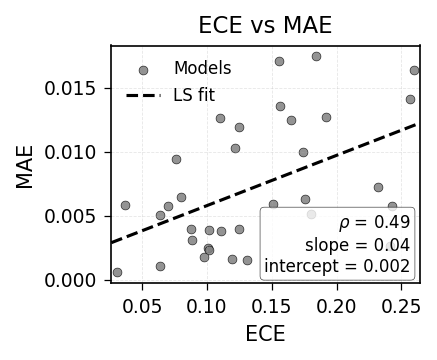

In [26]:
plot_ece_vs_mae(maes, eces, x_label="MAE", y_label="ECE", title="ECE vs MAE", mae_thresh=0.02, z_thresh=None, pdf_path="ece_vs_mae.pdf", flip=True)

Removed 6 points as outliers.
Least-squares fit: slope = 6.086, intercept = 0.092
Pearson correlation (MAE, ECE): 0.489 (p=0.0034)


(<Figure size 450x375 with 1 Axes>,
 <Axes: title={'center': 'ECE vs MAE'}, xlabel='MAE', ylabel='ECE'>)

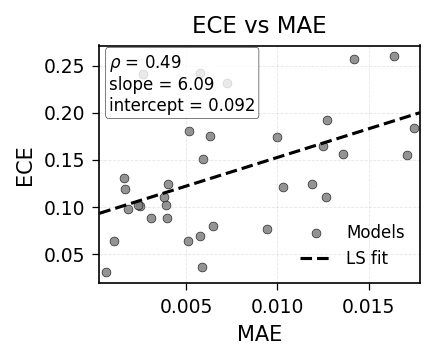

In [17]:
plot_ece_vs_mae(maes, eces, x_label="MAE", y_label="ECE", title="ECE vs MAE", mae_thresh=0.02, z_thresh=None, pdf_path="ece_vs_mae.pdf", flip=False)

In [ ]:
import numpy as np
from scipy.stats import pearsonr, zscore
import matplotlib.pyplot as plt

def plot_ece_vs_mae(
    maes,
    eces,
    x_label="MAE",
    y_label="ECE",
    title="ECE vs MAE",
    z_thresh=3.0,
    mae_thresh=0.05,
    ax=None,
    annotate_stats=True,
    pdf_path=None,
    flip=False,
):
    """
    Plot ECE vs MAE with outlier removal and least-squares fit.

    Parameters
    ----------
    maes, eces : array-like
        Data points.
    x_label, y_label, title : str
        Axis labels and plot title.
    z_thresh : float or None
        Z-score threshold for outlier removal. If None, no z-score filtering.
    mae_thresh : float or None
        Optional upper bound on MAE (keeps points with mae < mae_thresh).
    ax : matplotlib Axes or None
        If given, draw on this axes; otherwise create a new figure.
    annotate_stats : bool
        If True, annotate slope/intercept/correlation inside the plot.
    """

    # Convert to numpy arrays
    maes = np.asarray(maes, dtype=float)
    eces = np.asarray(eces, dtype=float)

    # Outlier mask
    if z_thresh is not None:
        z_mae = zscore(maes)
        z_ece = zscore(eces)
        mask = (np.abs(z_mae) < z_thresh) & (np.abs(z_ece) < z_thresh)
    else:
        mask = np.ones(len(maes), dtype=bool)

    if mae_thresh is not None:
        mask &= (maes < mae_thresh)

    filtered_maes = maes[mask]
    filtered_eces = eces[mask]

    removed = len(maes) - len(filtered_maes)
    if removed > 0:
        print(f"Removed {removed} points as outliers.")

    if len(filtered_maes) < 2:
        raise ValueError("Not enough points after filtering to fit a line.")

    # Create axes if needed
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.0, 2.5), dpi=150)
    else:
        fig = ax.figure

    # Scatter plot (small markers, black edge)
    ax.scatter(
        filtered_maes,
        filtered_eces,
        s=18,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.3,
        label="Models",
        color="gray",
    )

    # Least-squares fit: y = m * x + b
    slope, intercept = np.polyfit(filtered_maes, filtered_eces, 1)
    x_min, x_max = filtered_maes.min(), filtered_maes.max()
    x_pad = 0.02 * (x_max - x_min) if x_max > x_min else 0.001
    x_vals = np.linspace(x_min - x_pad, x_max + x_pad, 200)
    y_vals = slope * x_vals + intercept

    ax.plot(
        x_vals,
        y_vals,
        linestyle="--",
        linewidth=1.5,
        label="LS fit",
        color="black",
    )

    # Pearson correlation
    corr, pval = pearsonr(filtered_maes, filtered_eces)

    # Labels, title, style
    ax.set_xlabel(x_label, fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.3)

    # Tick params (smaller, thinner)
    ax.tick_params(axis="both", which="both", labelsize=9, width=0.6)

    # Tight axis limits with small padding
    y_min, y_max = filtered_eces.min(), filtered_eces.max()
    y_pad = 0.05 * (y_max - y_min) if y_max > y_min else 0.001
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    # Legend (small)
    ax.legend(frameon=False, fontsize=8)

    # Annotate stats inside the plot
    if annotate_stats:
        text = (
            rf"$\rho$ = {corr:.2f}" "\n"
            rf"slope = {slope:.2f}" "\n"
            rf"intercept = {intercept:.3f}"
        )
        ax.text(
            0.03,
            0.97,
            text,
            transform=ax.transAxes,
            fontsize=8,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, linewidth=0.3),
        )

    # Print stats to console as well
    print(f"Least-squares fit: slope = {slope:.3f}, intercept = {intercept:.3f}")
    print(f"Pearson correlation ({x_label}, {y_label}): {corr:.3f} (p={pval:.2g})")

    fig.tight_layout()
    if pdf_path is not None:
        fig.savefig(pdf_path, dpi=300)
    return fig, ax


Removed 6 outlier points (z-score > None)
Least-squares fit: slope = 3.728, intercept = 0.038
Pearson correlation (MAE, BRIER): 0.485 (p=0.0036)


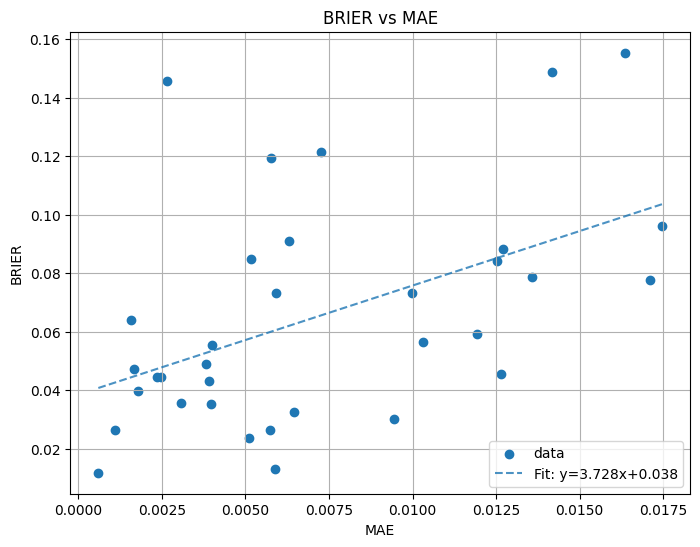

In [156]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8, 6))
# plt.scatter(maes, briers)
# plt.xlabel('MAE')
# plt.ylabel('BRIER')
# plt.title('BRIER vs MAE')
# plt.grid(True)
# plt.show()
plot_ece_vs_mae(maes, briers, x_label="MAE", y_label="BRIER", title="BRIER vs MAE", mae_thresh=0.02, z_thresh=None)